In [1]:
import os
import gc
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")
plt.rcParams['font.family'] = 'Arial'
plt.rcParams['axes.unicode_minus'] = False
folder_path = r'D:\clone\merged'

In [2]:
def load_and_aggregate_veg(files):

    def preprocess(ds):
        if 'valid_time' in ds.coords:
            ds = ds.rename({'valid_time': 'time'})
        if 'expver' in ds.dims:
            ds = ds.mean(dim='expver')
        return ds.sortby('time')

    df_list = []

    # map tên file → tên column chuẩn
    name_map = {
        'high_vegetation_cover_merged.nc': 'high_vegetation_cover',
        'low_vegetation_cover_merged.nc': 'low_vegetation_cover',
        'leaf_area_index_high_vegetation_merged.nc': 'leaf_area_index_high_vegetation',
        'leaf_area_index_low_vegetation_merged.nc': 'leaf_area_index_low_vegetation'
    }

    for f in files:
        path = os.path.join(folder_path, f)
        print("Processing:", path)

        ds = preprocess(xr.open_dataset(path))

        var = list(ds.data_vars)[0]
        print("Variable:", var)

        # reduce spatial + resample
        data = (
            ds[var]
            .mean(dim=['latitude', 'longitude'])
            .resample(time='1D')
            .mean()
        )

        # convert chuẩn (KHÔNG dùng values)
        df = data.to_dataframe(name=name_map[f])

        df_list.append(df)

        ds.close()
        gc.collect()

    # merge tất cả theo time index
    df_daily = pd.concat(df_list, axis=1)

    print("Columns:", df_daily.columns.tolist())

    # ✅ đảm bảo đủ cột trước khi tính
    required = [
        'leaf_area_index_high_vegetation',
        'leaf_area_index_low_vegetation',
        'high_vegetation_cover',
        'low_vegetation_cover'
    ]

    for col in required:
        if col not in df_daily.columns:
            raise ValueError(f"Thiếu cột: {col}")

    # tính toán
    df_daily['eff_lai_high'] = (
        df_daily['leaf_area_index_high_vegetation'] *
        df_daily['high_vegetation_cover']
    )

    df_daily['eff_lai_low'] = (
        df_daily['leaf_area_index_low_vegetation'] *
        df_daily['low_vegetation_cover']
    )

    df_daily['total_eff_lai'] = (
        df_daily['eff_lai_high'] +
        df_daily['eff_lai_low']
    )

    # climatology theo tháng
    climatology = df_daily.groupby(df_daily.index.month).mean()

    return df_daily, climatology

In [3]:
veg_files = [
    'high_vegetation_cover_merged.nc', 
    'low_vegetation_cover_merged.nc', 
    'leaf_area_index_high_vegetation_merged.nc',
    'leaf_area_index_low_vegetation_merged.nc'
]

df_daily, clim = load_and_aggregate_veg(veg_files)

Processing: D:\clone\merged\high_vegetation_cover_merged.nc
Variable: cvh
Processing: D:\clone\merged\low_vegetation_cover_merged.nc
Variable: cvl
Processing: D:\clone\merged\leaf_area_index_high_vegetation_merged.nc
Variable: lai_hv
Processing: D:\clone\merged\leaf_area_index_low_vegetation_merged.nc
Variable: lai_lv
Columns: ['number', 'high_vegetation_cover', 'number', 'low_vegetation_cover', 'number', 'leaf_area_index_high_vegetation', 'number', 'leaf_area_index_low_vegetation']


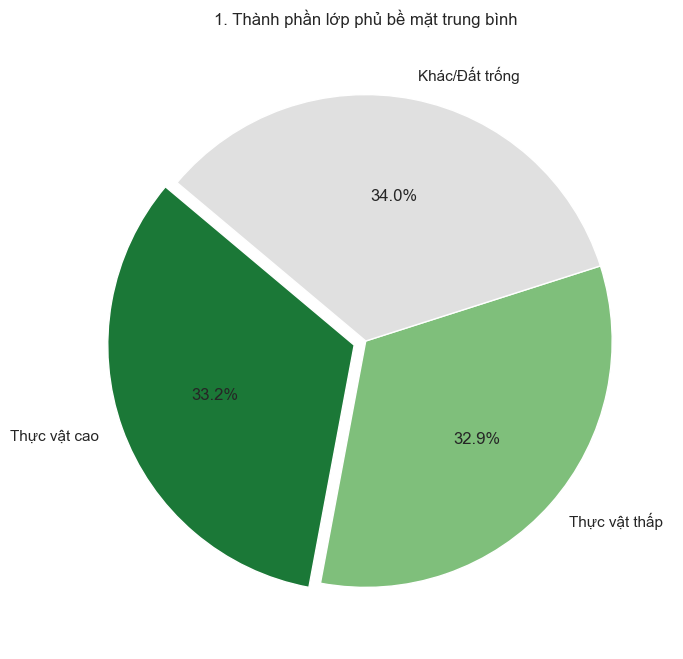

In [4]:
avg_hvc = clim['high_vegetation_cover'].mean()
avg_lvc = clim['low_vegetation_cover'].mean()
bare = max(0, 1 - (avg_hvc + avg_lvc))

plt.figure(figsize=(8, 8))
plt.pie([avg_hvc, avg_lvc, bare], labels=['Thực vật cao', 'Thực vật thấp', 'Khác/Đất trống'], 
        autopct='%1.1f%%', colors=['#1b7837', '#7fbf7b', '#e0e0e0'], startangle=140, explode=[0.05, 0, 0])
plt.title("1. Thành phần lớp phủ bề mặt trung bình")
plt.show()

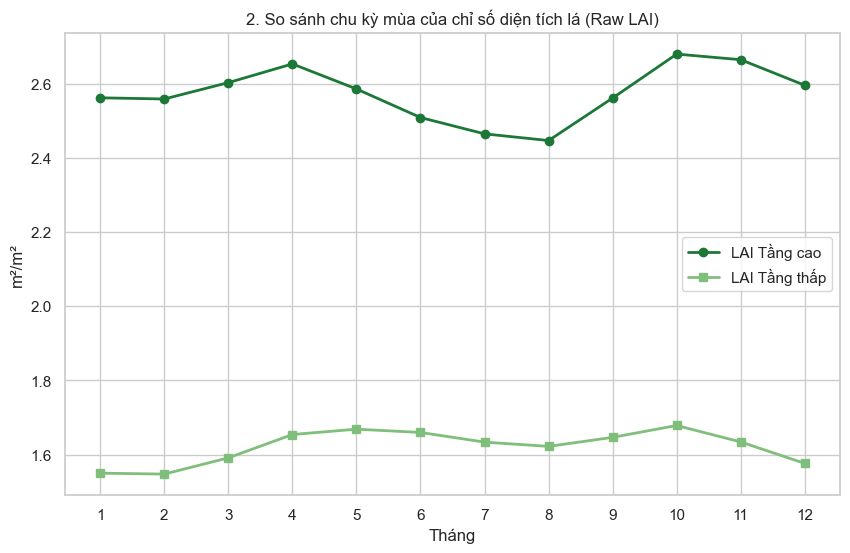

In [5]:
plt.figure(figsize=(10, 6))
plt.plot(clim.index, clim['leaf_area_index_high_vegetation'], color='#1b7837', marker='o', lw=2, label='LAI Tầng cao')
plt.plot(clim.index, clim['leaf_area_index_low_vegetation'], color='#7fbf7b', marker='s', lw=2, label='LAI Tầng thấp')
plt.title("2. So sánh chu kỳ mùa của chỉ số diện tích lá (Raw LAI)")
plt.xlabel("Tháng")
plt.ylabel("m²/m²")
plt.xticks(range(1, 13))
plt.legend()
plt.show()

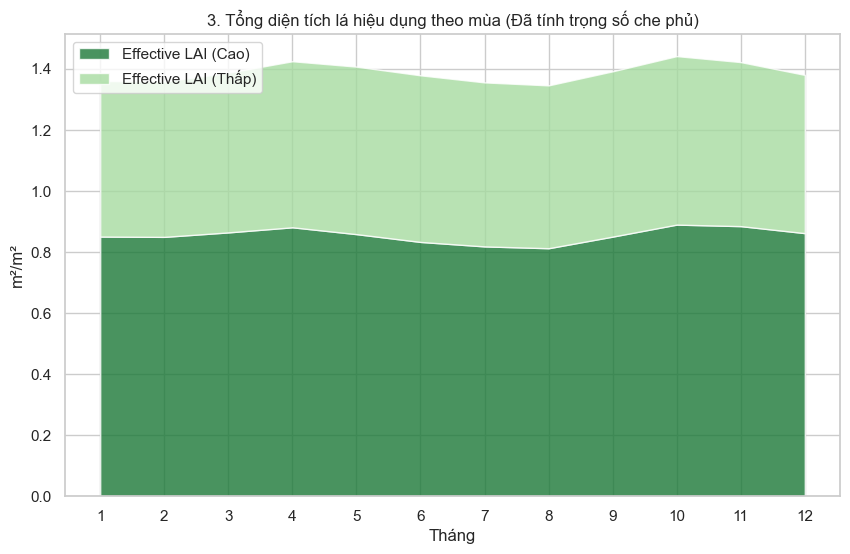

In [6]:
plt.figure(figsize=(10, 6))
plt.stackplot(clim.index, clim['eff_lai_high'], clim['eff_lai_low'], 
              labels=['Effective LAI (Cao)', 'Effective LAI (Thấp)'], colors=['#1b7837', '#a6dba0'], alpha=0.8)
plt.title("3. Tổng diện tích lá hiệu dụng theo mùa (Đã tính trọng số che phủ)")
plt.xlabel("Tháng")
plt.ylabel("m²/m²")
plt.xticks(range(1, 13))
plt.legend(loc='upper left')
plt.show()

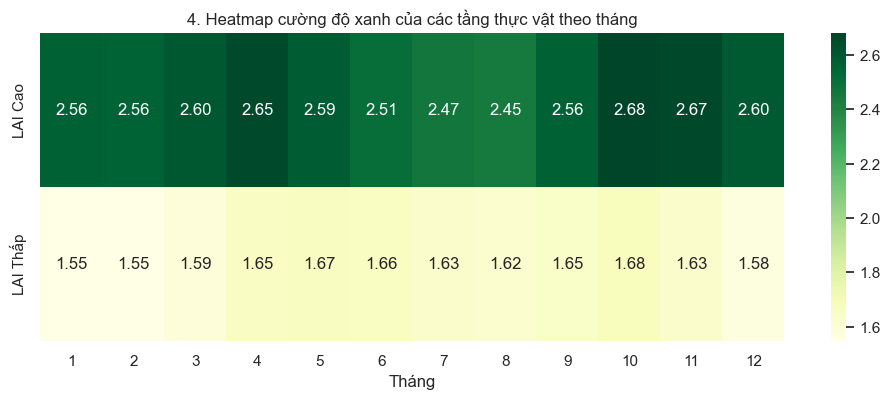

In [7]:
heatmap_data = clim[['leaf_area_index_high_vegetation', 'leaf_area_index_low_vegetation']].T
plt.figure(figsize=(12, 4))
sns.heatmap(heatmap_data, cmap="YlGn", annot=True, fmt=".2f", 
            yticklabels=['LAI Cao', 'LAI Thấp'], xticklabels=range(1, 13))
plt.title("4. Heatmap cường độ xanh của các tầng thực vật theo tháng")
plt.xlabel("Tháng")
plt.show()

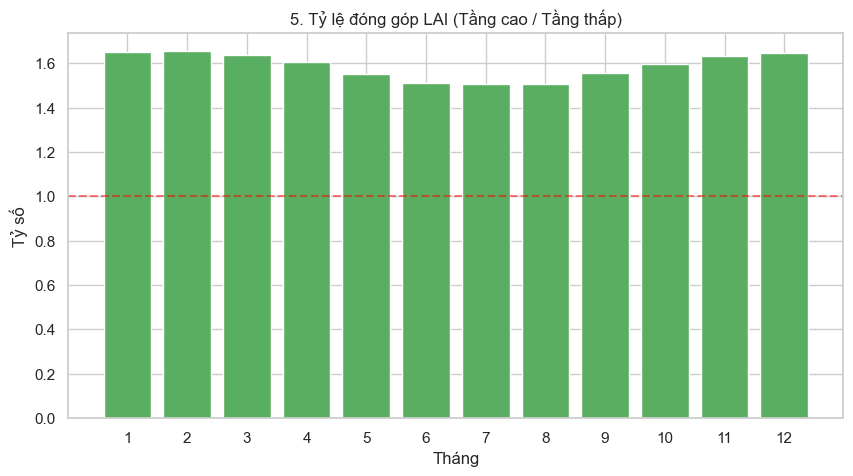

In [8]:
clim['ratio'] = clim['leaf_area_index_high_vegetation'] / clim['leaf_area_index_low_vegetation']
plt.figure(figsize=(10, 5))
plt.bar(clim.index, clim['ratio'], color='#5aae61')
plt.axhline(1, color='red', linestyle='--', alpha=0.5)
plt.title("5. Tỷ lệ đóng góp LAI (Tầng cao / Tầng thấp)")
plt.xlabel("Tháng")
plt.ylabel("Tỷ số")
plt.xticks(range(1, 13))
plt.show()

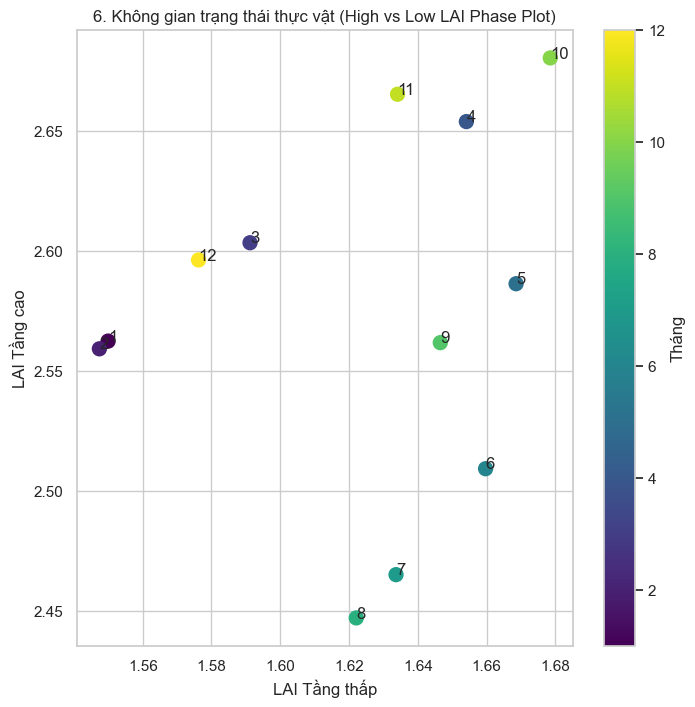

In [9]:
plt.figure(figsize=(8, 8))
plt.scatter(clim['leaf_area_index_low_vegetation'], clim['leaf_area_index_high_vegetation'], 
            c=clim.index, cmap='viridis', s=100)
for i, txt in enumerate(range(1, 13)):
    plt.annotate(txt, (clim['leaf_area_index_low_vegetation'].iloc[i], clim['leaf_area_index_high_vegetation'].iloc[i]))
plt.title("6. Không gian trạng thái thực vật (High vs Low LAI Phase Plot)")
plt.xlabel("LAI Tầng thấp")
plt.ylabel("LAI Tầng cao")
plt.colorbar(label='Tháng')
plt.show()

In [10]:
try:
    df_sw = pd.read_csv(os.path.join(folder_path, 'derived_soil_moisture_daily.csv'), index_col=0, parse_dates=True)
    sw_clim = df_sw['swvl1'].groupby(df_sw.index.month).mean()
    
    fig, ax1 = plt.subplots(figsize=(10, 6))
    ax1.plot(clim.index, clim['total_eff_lai'], color='green', lw=3, label='Tổng Effective LAI')
    ax1.set_ylabel('LAI (m²/m²)', color='green')
    
    ax2 = ax1.twinx()
    ax2.plot(sw_clim.index, sw_clim.values, color='blue', ls='--', label='Độ ẩm đất (L1)')
    ax2.set_ylabel('Độ ẩm đất (m³/m³)', color='blue')
    
    plt.title("7. Tương quan chu kỳ mùa giữa thực vật và độ ẩm đất")
    ax1.legend(loc='upper left'); ax2.legend(loc='upper right')
    plt.xticks(range(1, 13))
    plt.show()
except:
    print("Cần file dữ liệu độ ẩm đất từ các NB trước để vẽ biểu đồ này.")

Cần file dữ liệu độ ẩm đất từ các NB trước để vẽ biểu đồ này.


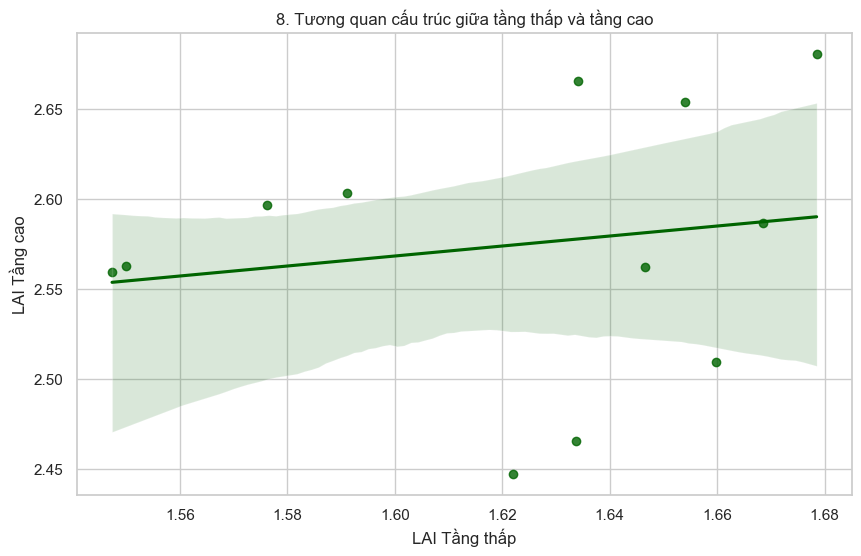

In [11]:
plt.figure(figsize=(10, 6))
sns.regplot(x=clim['leaf_area_index_low_vegetation'], y=clim['leaf_area_index_high_vegetation'], color='darkgreen')
plt.title("8. Tương quan cấu trúc giữa tầng thấp và tầng cao")
plt.xlabel("LAI Tầng thấp")
plt.ylabel("LAI Tầng cao")
plt.show()